In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import shutil
import os

drive_path = "/content/drive/MyDrive/Dataset/Dataset"
local_path = "/content/Dataset"

if not os.path.exists(local_path):
    shutil.copytree(drive_path, local_path)

print("Dataset ready at:", local_path)

Dataset ready at: /content/Dataset


In [3]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.RandomAffine(degrees=0, translate=(0.05,0.05)),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

val_test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

In [4]:
from torchvision import datasets
from sklearn.model_selection import train_test_split
from torch.utils.data import Subset, DataLoader
import numpy as np

full_dataset = datasets.ImageFolder(local_path)

targets = np.array(full_dataset.targets)

train_idx, temp_idx = train_test_split(
    np.arange(len(targets)),
    test_size=0.3,
    stratify=targets,
    random_state=42
)

val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.5,
    stratify=targets[temp_idx],
    random_state=42
)

train_dataset = Subset(datasets.ImageFolder(local_path, transform=train_transform), train_idx)
val_dataset = Subset(datasets.ImageFolder(local_path, transform=val_test_transform), val_idx)
test_dataset = Subset(datasets.ImageFolder(local_path, transform=val_test_transform), test_idx)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

print(len(train_dataset), len(val_dataset), len(test_dataset))

4426 948 949


In [5]:
import torch
import torch.nn as nn
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.vgg16(weights="IMAGENET1K_V1")

# Freeze early layers
for param in model.features[:20].parameters():
    param.requires_grad = False

# Replace classifier
model.classifier[6] = nn.Sequential(
    nn.Linear(4096, 512),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(512, 5)
)

model = model.to(device)

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:09<00:00, 59.1MB/s]


In [6]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=3
)

In [7]:
best_val_acc = 0

for epoch in range(20):

    model.train()
    correct = 0
    total = 0

    for batch_idx, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        if batch_idx % 20 == 0:
            print(f"Epoch {epoch+1} | Batch {batch_idx}/{len(train_loader)}")

    train_acc = correct / total

    # Validation
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_acc = correct / total

    scheduler.step(val_acc)

    print(f"Epoch {epoch+1}/20")
    print("Train Acc:", train_acc)
    print("Val Acc:", val_acc)
    print("----------------------")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "/content/drive/MyDrive/best_vgg16_clean.pth")
        print("✅ Best model saved")

print("🔥 Training complete")

Epoch 1 | Batch 0/139
Epoch 1 | Batch 20/139
Epoch 1 | Batch 40/139
Epoch 1 | Batch 60/139
Epoch 1 | Batch 80/139
Epoch 1 | Batch 100/139
Epoch 1 | Batch 120/139
Epoch 1/20
Train Acc: 0.5784003615002259
Val Acc: 0.6729957805907173
----------------------
✅ Best model saved
Epoch 2 | Batch 0/139
Epoch 2 | Batch 20/139
Epoch 2 | Batch 40/139
Epoch 2 | Batch 60/139
Epoch 2 | Batch 80/139
Epoch 2 | Batch 100/139
Epoch 2 | Batch 120/139
Epoch 2/20
Train Acc: 0.7157704473565296
Val Acc: 0.7552742616033755
----------------------
✅ Best model saved
Epoch 3 | Batch 0/139
Epoch 3 | Batch 20/139
Epoch 3 | Batch 40/139
Epoch 3 | Batch 60/139
Epoch 3 | Batch 80/139
Epoch 3 | Batch 100/139
Epoch 3 | Batch 120/139
Epoch 3/20
Train Acc: 0.8000451875282422
Val Acc: 0.8386075949367089
----------------------
✅ Best model saved
Epoch 4 | Batch 0/139
Epoch 4 | Batch 20/139
Epoch 4 | Batch 40/139
Epoch 4 | Batch 60/139
Epoch 4 | Batch 80/139
Epoch 4 | Batch 100/139
Epoch 4 | Batch 120/139
Epoch 4/20
Train Ac

In [8]:
import torch

model.load_state_dict(torch.load("/content/drive/MyDrive/best_vgg16_clean.pth"))
model.eval()

print("✅ Best model loaded")

✅ Best model loaded


In [9]:
def compute_accuracy(model, loader):
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return correct / total


train_acc = compute_accuracy(model, train_loader)
val_acc   = compute_accuracy(model, val_loader)
test_acc  = compute_accuracy(model, test_loader)

print("Training Accuracy:", train_acc)
print("Validation Accuracy:", val_acc)
print("Test Accuracy:", test_acc)

Training Accuracy: 0.9900587437867149
Validation Accuracy: 0.979957805907173
Test Accuracy: 0.9567966280295047


In [11]:
!pip install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 75.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44285 sha256=7bece862698ff70b89e764868dc12b85d3d311a89c4fd618b07322ef9dfe3c87
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


In [12]:
import torch
import torch.nn as nn
import numpy as np
import cv2
import matplotlib.pyplot as plt
from torchvision import models
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

In [16]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.vgg16(pretrained=False)

In [17]:
model.classifier[6] = nn.Sequential(
    nn.Linear(4096, 1024),
    nn.ReLU(inplace=True),
    nn.Dropout(0.5),
    nn.Linear(1024, 5)
)

In [19]:
import torch
import torch.nn as nn
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.vgg16(pretrained=False)

# 🔥 EXACT structure used during training
model.classifier[6] = nn.Sequential(
    nn.Linear(4096, 512),
    nn.ReLU(inplace=True),
    nn.Dropout(0.5),
    nn.Linear(512, 5)
)

model.load_state_dict(torch.load(
    "/content/drive/MyDrive/best_vgg16_clean.pth",
    map_location=device
))

model.to(device)
model.eval()

print("✅ VGG16 loaded successfully")

✅ VGG16 loaded successfully


In [20]:
target_layer = model.features[-1]

In [21]:
# Get one batch from test loader
images, labels = next(iter(test_loader))

img_tensor = images[0].unsqueeze(0).to(device)
true_label = labels[0].item()

# Predict
with torch.no_grad():
    output = model(img_tensor)
    pred_class = torch.argmax(output, dim=1).item()

print("True label:", true_label)
print("Predicted label:", pred_class)

True label: 4
Predicted label: 4


In [22]:
cam = GradCAM(model=model, target_layers=[target_layer])

grayscale_cam = cam(input_tensor=img_tensor)
grayscale_cam = grayscale_cam[0]

In [23]:
# Convert tensor to numpy
img_np = images[0].permute(1, 2, 0).cpu().numpy()

# Undo normalization (ImageNet stats)
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
img_np = std * img_np + mean
img_np = np.clip(img_np, 0, 1)

# Overlay heatmap
visualization = show_cam_on_image(img_np.astype(np.float32),
                                  grayscale_cam,
                                  use_rgb=True)

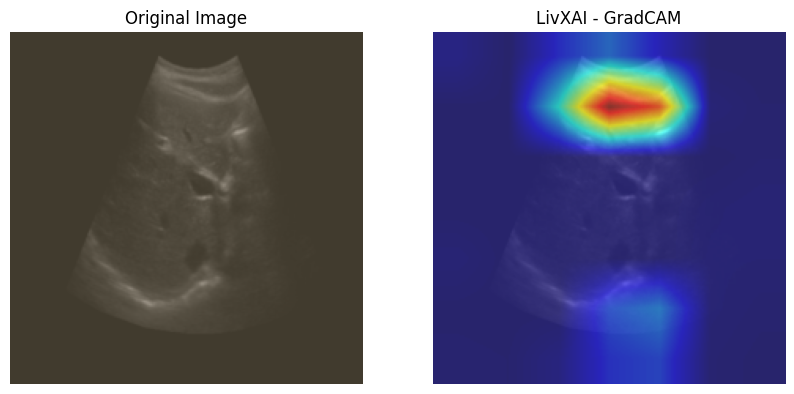

In [24]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(img_np)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(visualization)
plt.title("LivXAI - GradCAM")
plt.axis("off")

plt.show()

In [25]:
!pip install grad-cam -q

In [26]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torchvision import models
from pytorch_grad_cam import GradCAMPlusPlus
from pytorch_grad_cam.utils.image import show_cam_on_image

In [27]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.vgg16(pretrained=False)

# EXACT classifier used during training
model.classifier[6] = nn.Sequential(
    nn.Linear(4096, 512),
    nn.ReLU(inplace=True),
    nn.Dropout(0.5),
    nn.Linear(512, 5)
)

model.load_state_dict(torch.load(
    "/content/drive/MyDrive/best_vgg16_clean.pth",
    map_location=device
))

model.to(device)
model.eval()

print("✅ Model loaded successfully")

✅ Model loaded successfully


In [28]:
target_layers = [model.features[-1]]

cam = GradCAMPlusPlus(
    model=model,
    target_layers=target_layers
)

True Label: F4
Predicted: F4


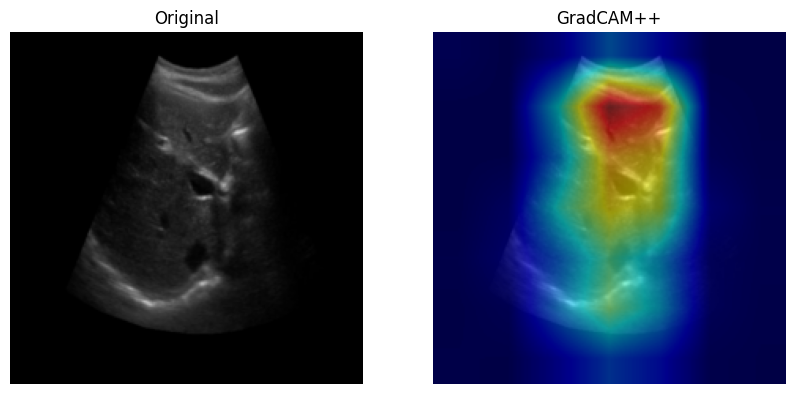

In [29]:
class_names = ["F0", "F1", "F2", "F3", "F4"]

# Loop until we find correctly predicted image
for images, labels in test_loader:
    images = images.to(device)
    labels = labels.to(device)

    outputs = model(images)
    preds = torch.argmax(outputs, dim=1)

    for i in range(len(images)):
        if preds[i] == labels[i]:

            input_tensor = images[i].unsqueeze(0)

            grayscale_cam = cam(input_tensor=input_tensor)
            grayscale_cam = grayscale_cam[0]

            # Convert image for visualization
            img = images[i].cpu().permute(1,2,0).numpy()

            # Undo normalization (IMPORTANT)
            mean = np.array([0.5,0.5,0.5])
            std = np.array([0.5,0.5,0.5])
            img = std * img + mean
            img = np.clip(img, 0, 1)

            visualization = show_cam_on_image(
                img.astype(np.float32),
                grayscale_cam,
                use_rgb=True
            )

            print("True Label:", class_names[labels[i]])
            print("Predicted:", class_names[preds[i]])

            plt.figure(figsize=(10,5))

            plt.subplot(1,2,1)
            plt.imshow(img)
            plt.title("Original")
            plt.axis("off")

            plt.subplot(1,2,2)
            plt.imshow(visualization)
            plt.title("GradCAM++")
            plt.axis("off")

            plt.show()

            break
    break

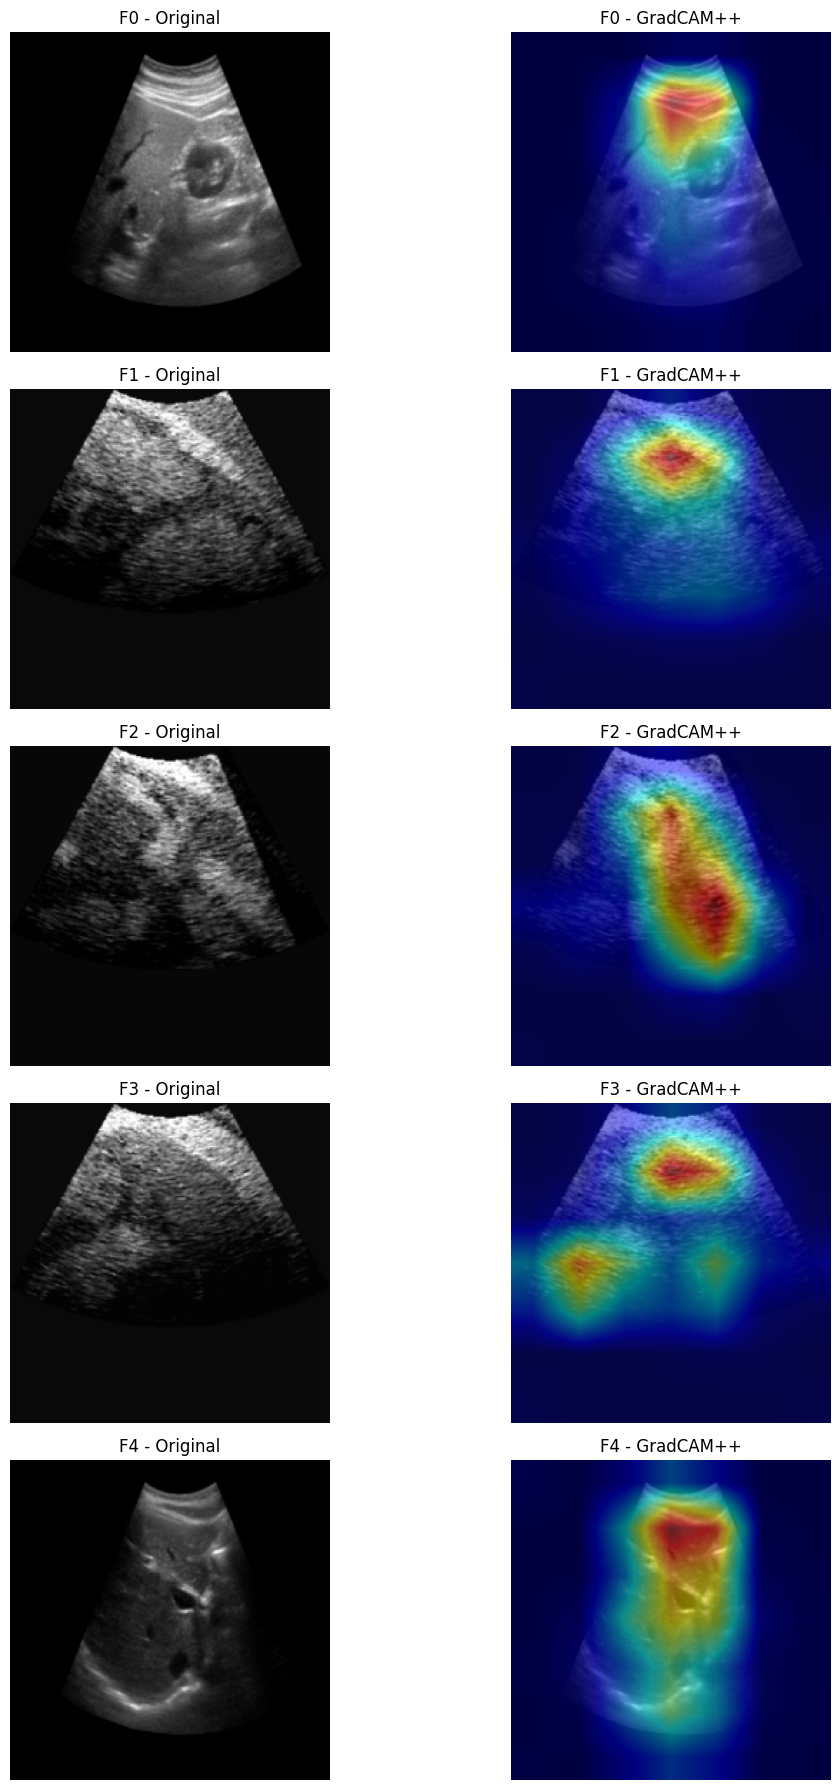

In [30]:
# Install if not installed
!pip install grad-cam -q

import torch
import numpy as np
import matplotlib.pyplot as plt
import cv2
from pytorch_grad_cam import GradCAMPlusPlus
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.eval()

# Change according to your model
target_layer = model.features[-1]  # For VGG16
# For EfficientNet use:
# target_layer = model.features[-1]

class_names = ['F0','F1','F2','F3','F4']

# Create GradCAM++
cam = GradCAMPlusPlus(model=model, target_layers=[target_layer])

found_stages = {}

for images, labels in test_loader:
    images = images.to(device)
    labels = labels.to(device)

    outputs = model(images)
    preds = torch.argmax(outputs, dim=1)

    for i in range(len(labels)):
        true_label = labels[i].item()
        pred_label = preds[i].item()

        if true_label == pred_label and true_label not in found_stages:

            input_tensor = images[i].unsqueeze(0)

            targets = [ClassifierOutputTarget(true_label)]
            grayscale_cam = cam(input_tensor=input_tensor, targets=targets)
            grayscale_cam = grayscale_cam[0]

            img = images[i].cpu().permute(1,2,0).numpy()
            img = (img - img.min()) / (img.max() - img.min())

            visualization = show_cam_on_image(img, grayscale_cam, use_rgb=True)

            found_stages[true_label] = (img, visualization)

    if len(found_stages) == 5:
        break

# ----------------- PLOT -----------------
plt.figure(figsize=(12,18))

for stage in range(5):
    if stage in found_stages:
        original, cam_img = found_stages[stage]

        plt.subplot(5,2,2*stage+1)
        plt.imshow(original)
        plt.title(f"{class_names[stage]} - Original")
        plt.axis("off")

        plt.subplot(5,2,2*stage+2)
        plt.imshow(cam_img)
        plt.title(f"{class_names[stage]} - GradCAM++")
        plt.axis("off")

plt.tight_layout()
plt.show()

In [31]:
!pip install grad-cam

In [34]:
import torch
import torch.nn as nn
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.vgg16(pretrained=False)

# 🔥 EXACT structure used during training
model.classifier[6] = nn.Sequential(
    nn.Linear(4096, 512),
    nn.ReLU(inplace=True),
    nn.Dropout(0.5),
    nn.Linear(512, 5)
)

model.load_state_dict(torch.load(
    "/content/drive/MyDrive/best_vgg16_clean.pth",
    map_location=device
))

model.to(device)
model.eval()

print("✅ VGG16 loaded successfully")

✅ VGG16 loaded successfully


100%|██████████| 32/32 [00:02<00:00, 13.42it/s]


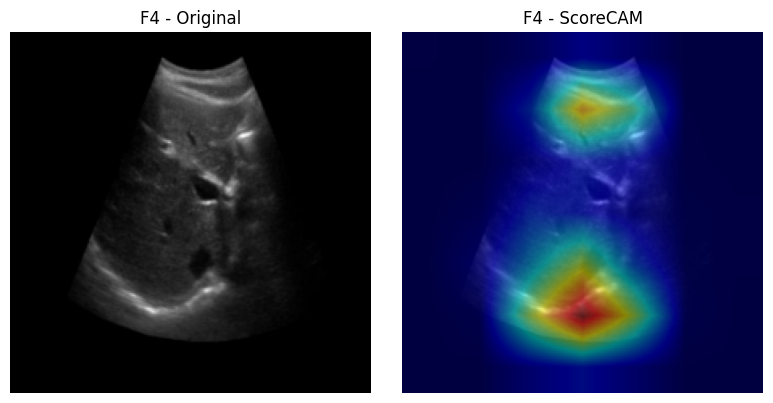

100%|██████████| 32/32 [00:02<00:00, 13.72it/s]


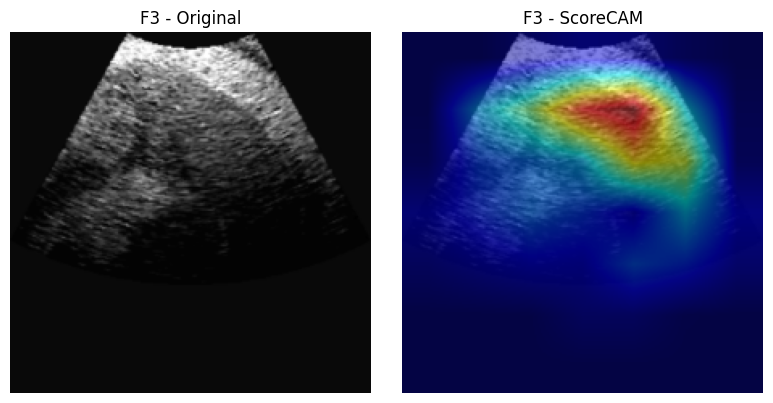

100%|██████████| 32/32 [00:02<00:00, 13.59it/s]


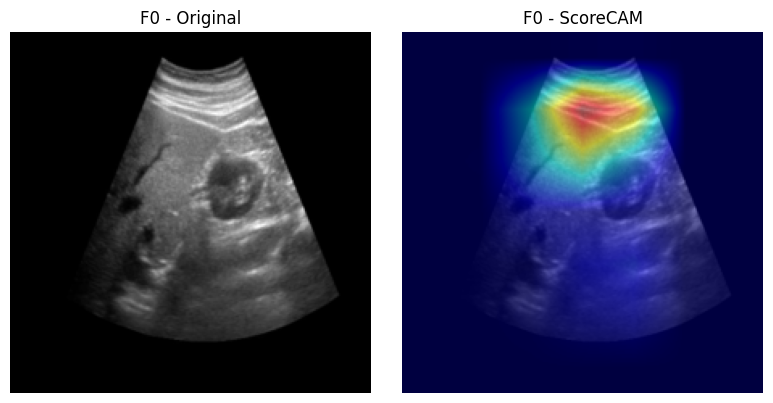

100%|██████████| 32/32 [00:02<00:00, 13.60it/s]


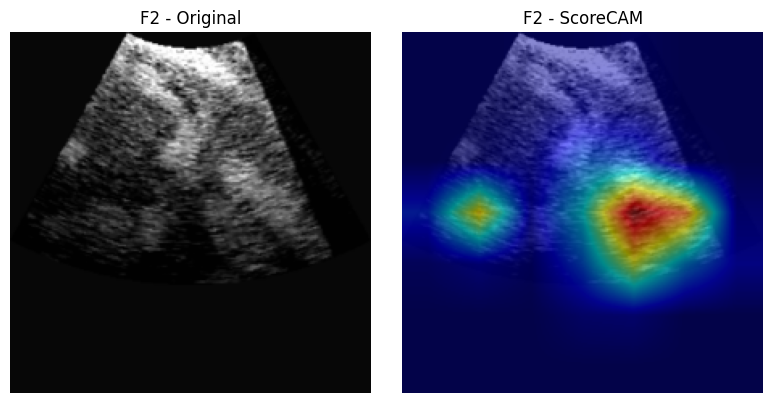

100%|██████████| 32/32 [00:02<00:00, 13.59it/s]


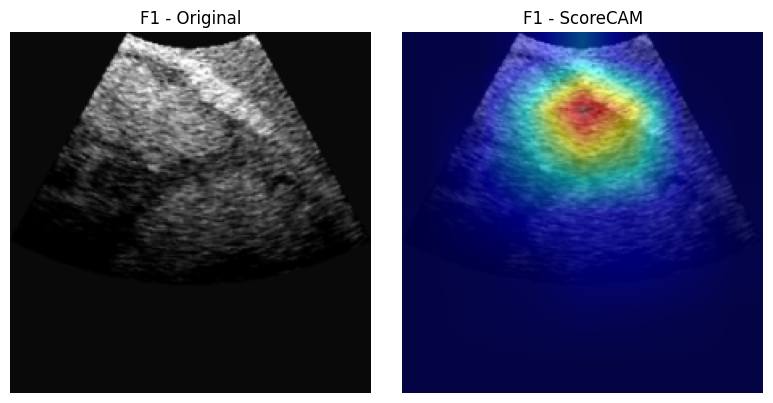

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from pytorch_grad_cam import ScoreCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

# Target last conv layer
target_layers = [model.features[-1]]

cam = ScoreCAM(model=model, target_layers=target_layers)

class_names = ['F0','F1','F2','F3','F4']

count_per_class = {i:0 for i in range(5)}

for images, labels in test_loader:

    images = images.to(device)
    labels = labels.to(device)

    outputs = model(images)
    preds = torch.argmax(outputs, dim=1)

    for i in range(images.size(0)):

        label = labels[i].item()

        # Take only 1 image per class
        if count_per_class[label] >= 1:
            continue

        input_tensor = images[i].unsqueeze(0)

        targets = [ClassifierOutputTarget(label)]

        grayscale_cam = cam(input_tensor=input_tensor,
                            targets=targets)[0]

        # Convert image for visualization
        img = images[i].cpu().numpy().transpose(1,2,0)
        img = (img - img.min()) / (img.max() - img.min())

        visualization = show_cam_on_image(img,
                                          grayscale_cam,
                                          use_rgb=True)

        plt.figure(figsize=(8,4))

        plt.subplot(1,2,1)
        plt.imshow(img)
        plt.title(f"{class_names[label]} - Original")
        plt.axis("off")

        plt.subplot(1,2,2)
        plt.imshow(visualization)
        plt.title(f"{class_names[label]} - ScoreCAM")
        plt.axis("off")

        plt.tight_layout()
        plt.show()

        count_per_class[label] += 1

    if all(v >= 1 for v in count_per_class.values()):
        break